# Where do you set the threshold? Tuning a sanctions screening engine

**Kofi Gilbert** | MBA Business Analytics (STEM), DePaul University

Sanctions screening is the control that decides whether a bank onboards a sanctioned
party. Everyone describes it as a matching problem. It isn't. Matching is the easy
half — the hard half is choosing where to draw the line, because the two ways of being
wrong cost wildly different things:

- **A missed true match** is a regulatory failure. It is the thing the control exists
  to prevent.
- **A false positive** costs an analyst twenty minutes.

Those are not symmetric, so the threshold should not sit where accuracy is highest.
It should sit where the *recall you need* costs the *least review time you can live
with*. This notebook builds the engine, then measures that tradeoff explicitly.

Everything below runs against [`src/screening`](src/screening) in this repo.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from screening import Watchlist, screen
from screening.engine import Thresholds
from screening.match import similarity, phonetic_key
from screening.normalize import normalize

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (13, 6.5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

HIT   = "#c44e52"   # red    = true matches (the ones you cannot miss)
CLEAN = "#4c72b0"   # blue   = clean parties
ACCENT= "#ff7f0e"   # orange = the chosen operating point
MUTED = "#8c8c8c"

watchlist = Watchlist.from_csv("data/sample_sdn.csv")
print(f"watchlist: {len(watchlist)} entries, "
      f"{sum(len(e.aliases) for e in watchlist.entries)} aliases")

watchlist: 10 entries, 20 aliases


## 1. Why one matching signal is never enough

Real name data breaks each metric in a different way. Take four pairs that a
compliance analyst would call the same party, plus one that clearly isn't, and score
them with each signal separately.

In [2]:
pairs = [
    ("Mohammed Al-Amin Hassan", "Muhammad Al Amin Hassan", "transliteration"),
    ("Sergei Ivanovich Volkov", "Volkov, Sergei Ivanovich", "reordered"),
    ("Northern Star Trading Company Limited", "Northern Star Trading Co., Ltd.", "legal form"),
    ("Olena Kovalenko", "Elena Kovalenko",  "spelling variant"),
    ("Margaret Thompson-Reilly", "Chen Wei Ming", "unrelated (control)"),
]

rows = []
for a, b, kind in pairs:
    s = similarity(a, b)
    rows.append({"pair": kind, "jaro-winkler": s.jaro, "token-set": s.token,
                 "phonetic": s.phonetic, "combined": s.combined})
signals = pd.DataFrame(rows).set_index("pair").round(3)
signals

,jaro-winkler,token-set,phonetic,combined
pair,,,,
transliteration,0.848,0.600,1.000,0.767
reordered,0.763,1.000,1.000,0.917
legal form,1.000,1.000,1.000,1.000
spelling variant,0.932,0.333,0.722,0.621
unrelated (control),0.525,0.000,0.481,0.280


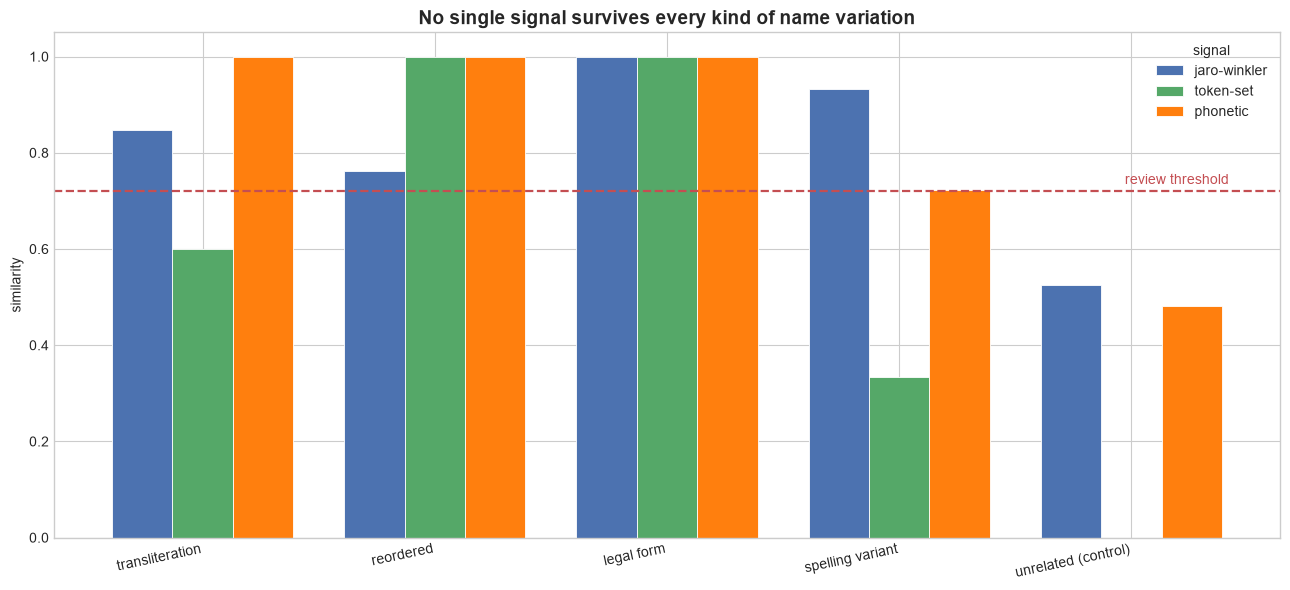

In [3]:
ax = signals[["jaro-winkler", "token-set", "phonetic"]].plot(
    kind="bar", figsize=(13, 6), width=0.78,
    color=[CLEAN, "#55a868", ACCENT], edgecolor="white", linewidth=0.6)
ax.axhline(0.72, color=HIT, ls="--", lw=1.6)
ax.text(4.42, 0.735, "review threshold", color=HIT, fontsize=10, ha="right")
ax.set_title("No single signal survives every kind of name variation")
ax.set_ylabel("similarity"); ax.set_xlabel("")
ax.set_ylim(0, 1.05)
ax.legend(title="signal", loc="upper right", framealpha=0.95)
plt.xticks(rotation=12, ha="right")
plt.tight_layout(); plt.show()

**Reading:** look at the gaps, not the heights.

*Reordered* names crater under Jaro-Winkler — character-position distance has no idea
that "Volkov, Sergei" is the same human as "Sergei Ivanovich Volkov" — while token
overlap scores it near the top. *Transliteration* does the reverse: "Mohammed" and
"Muhammad" share few characters in the same positions and few whole tokens, but their
consonant skeletons are identical, so only the phonetic key rescues them. *Legal form*
is handled before any of this, in normalization, by stripping corporate suffixes.

Any single column here would miss a real sanctioned party. The combined score is
weighted `0.35 / 0.45 / 0.20`, leaning on token overlap because reordering and partial
names are the most common real-world variation — and the control name stays far below
the line regardless.

## 2. The tradeoff, measured

Now the actual question. I build a screening population: 40 parties who ARE on the
list (each written the messy way a real onboarding form would spell them) and 260 who
are not. Then I sweep the threshold from permissive to strict and record what each
setting would cost.

In [4]:
rng = np.random.default_rng(7)

def corrupt(name, rng):
    '''Spell a name the way an onboarding form actually would: reordered, initialised,
    transliterated, or lightly typo-ed. This is what screening really faces.'''
    parts = name.split()
    mode = rng.integers(0, 4)
    if mode == 0 and len(parts) > 1:                 # reorder
        return f"{parts[-1]}, {' '.join(parts[:-1])}"
    if mode == 1 and len(parts) > 2:                 # middle name to initial
        return f"{parts[0]} {parts[1][0]}. {parts[-1]}"
    if mode == 2:                                    # transliteration drift
        out = name
        for a, b in (("ei", "ey"), ("ov", "off"), ("Mohammed", "Muhammad"),
                     ("ss", "s"), ("kh", "k")):
            out = out.replace(a, b)
        return out
    chars = list(name)                                # single-character typo
    i = int(rng.integers(1, len(chars)))
    if chars[i] != " ":
        chars[i] = rng.choice(list("aeiourstln"))
    return "".join(chars)

CLEAN_NAMES = [
    "Margaret Thompson-Reilly", "David Okoye", "Priya Raghunathan", "Ana Lucia Ferreira",
    "Thomas Berg", "Yuki Tanaka", "Samuel Adjei", "Claire Beaumont", "Ibrahim Sowe",
    "Helen Vasquez", "Peter Nkemdirim", "Laura Kowalski", "Marcus Boateng",
    "Sophie Lindqvist", "Daniel Mensah", "Ruth Abrahams", "Felix Nwosu", "Grace Mutiso",
]

true_names, clean_names = [], []
for _ in range(40):
    entry = watchlist.entries[int(rng.integers(0, len(watchlist)))]
    source = entry.all_names()[int(rng.integers(0, len(entry.all_names())))]
    true_names.append(corrupt(source, rng))
for i in range(260):
    base = CLEAN_NAMES[i % len(CLEAN_NAMES)]
    clean_names.append(corrupt(base, rng) if i >= len(CLEAN_NAMES) else base)

def top_score(name):
    '''Best score this name reaches against any watchlist entry or alias.'''
    best = 0.0
    for entry in watchlist.entries:
        for candidate in entry.all_names():
            best = max(best, similarity(name, candidate).combined)
    return best

true_scores  = np.array([top_score(n) for n in true_names])
clean_scores = np.array([top_score(n) for n in clean_names])
print(f"population: {len(true_scores)} sanctioned, {len(clean_scores)} clean")
print(f"true matches  — median score {np.median(true_scores):.3f}")
print(f"clean parties — median score {np.median(clean_scores):.3f}")

population: 40 sanctioned, 260 clean
true matches  — median score 0.795
clean parties — median score 0.341


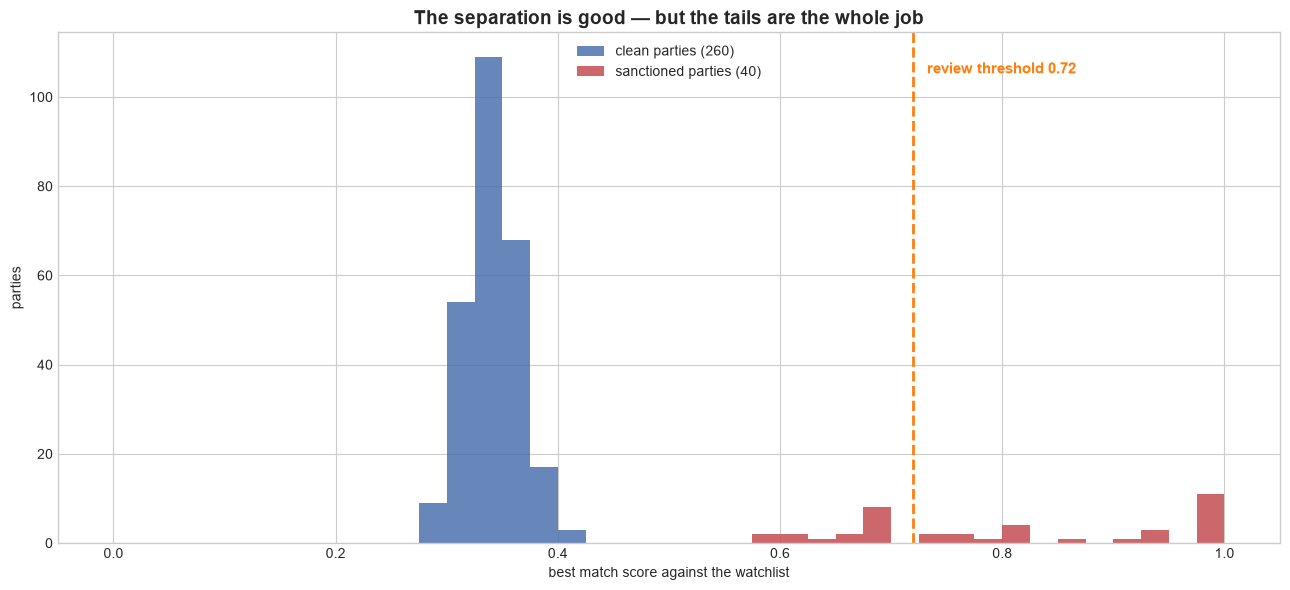

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))
bins = np.linspace(0, 1, 41)
ax.hist(clean_scores, bins=bins, color=CLEAN, alpha=0.85, label="clean parties (260)")
ax.hist(true_scores,  bins=bins, color=HIT,   alpha=0.85, label="sanctioned parties (40)")
ax.axvline(0.72, color=ACCENT, ls="--", lw=2)
ax.text(0.725, ax.get_ylim()[1] * 0.92, "  review threshold 0.72",
        color=ACCENT, fontsize=11, fontweight="bold")
ax.set_title("The separation is good — but the tails are the whole job")
ax.set_xlabel("best match score against the watchlist"); ax.set_ylabel("parties")
ax.legend(loc="upper center", framealpha=0.95)
plt.tight_layout(); plt.show()

**Reading:** the two populations separate cleanly in the middle and overlap at the
edges — and the edges are where every real decision lives. Anything you do to catch
the sanctioned parties stacked near the threshold also drags clean parties into the
queue with them. That is the tradeoff; the histogram just shows it has no free lunch.

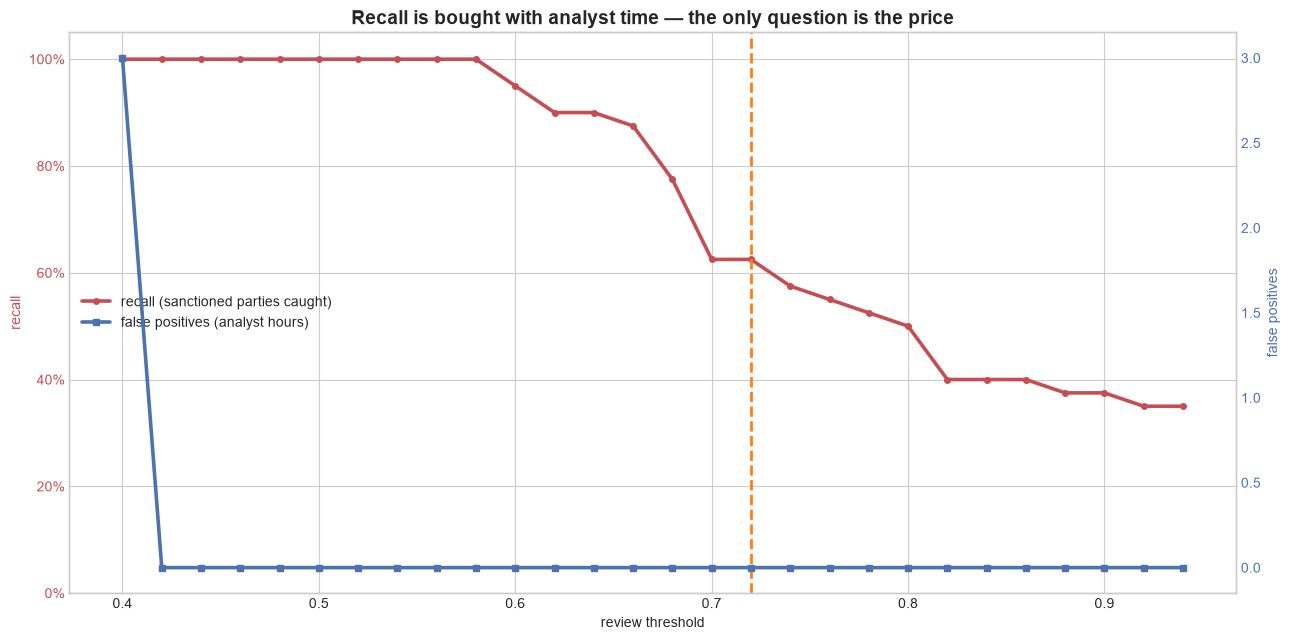

,recall,missed,false positives,alerts,precision
threshold,,,,,
0.60,0.950,2,0,38,1.0
0.62,0.900,4,0,36,1.0
0.64,0.900,4,0,36,1.0
0.66,0.875,5,0,35,1.0
0.68,0.775,9,0,31,1.0
0.70,0.625,15,0,25,1.0
0.72,0.625,15,0,25,1.0
0.74,0.575,17,0,23,1.0
0.76,0.550,18,0,22,1.0


In [6]:
grid = np.round(np.arange(0.40, 0.96, 0.02), 2)
recs = []
for t in grid:
    caught = int((true_scores >= t).sum())
    fps    = int((clean_scores >= t).sum())
    recs.append({
        "threshold": t,
        "recall": caught / len(true_scores),
        "missed": len(true_scores) - caught,
        "false positives": fps,
        "alerts": caught + fps,
        "precision": caught / (caught + fps) if (caught + fps) else np.nan,
    })
sweep = pd.DataFrame(recs)

fig, ax1 = plt.subplots(figsize=(13, 6.5))
ax1.plot(sweep["threshold"], sweep["recall"], color=HIT, lw=2.6,
         marker="o", ms=4, label="recall (sanctioned parties caught)")
ax1.set_ylabel("recall", color=HIT); ax1.tick_params(axis="y", labelcolor=HIT)
ax1.yaxis.set_major_formatter(PercentFormatter(1.0))
ax1.set_ylim(0, 1.05); ax1.set_xlabel("review threshold")

ax2 = ax1.twinx()
ax2.plot(sweep["threshold"], sweep["false positives"], color=CLEAN, lw=2.6,
         marker="s", ms=4, label="false positives (analyst hours)")
ax2.set_ylabel("false positives", color=CLEAN); ax2.tick_params(axis="y", labelcolor=CLEAN)
ax2.grid(False)

ax1.axvline(0.72, color=ACCENT, ls="--", lw=2)
ax1.set_title("Recall is bought with analyst time — the only question is the price")
lines = ax1.get_lines()[:1] + ax2.get_lines()[:1]
ax1.legend(lines, [l.get_label() for l in lines], loc="center left", framealpha=0.95)
plt.tight_layout(); plt.show()

sweep[(sweep.threshold >= 0.60) & (sweep.threshold <= 0.86)].set_index("threshold").round(3)

**Reading:** the two curves fall at different speeds, and that difference is the entire
argument.

Loosening the threshold buys recall quickly at first and then barely at all, while the
false-positive count keeps climbing — every step down past a point adds review hours
without adding safety. Tightening it does the reverse and starts silently dropping true
matches, which is the failure mode that shows up in an examination rather than in a
queue metric.

The engine defaults to **0.72 for REVIEW** and **0.88 for ESCALATE**, and the second
number matters as much as the first: it means the strongest hits go straight to the AML
officer instead of queueing behind routine noise. What a threshold sweep can't tell you
is where your own risk appetite sits — so the thresholds are configurable, and every
alert records the ones it was raised under.

## 3. Aliases are not a footnote

A large share of true hits never match the primary name at all. If aliases are screened
with anything less than equal weight, those parties walk straight through.

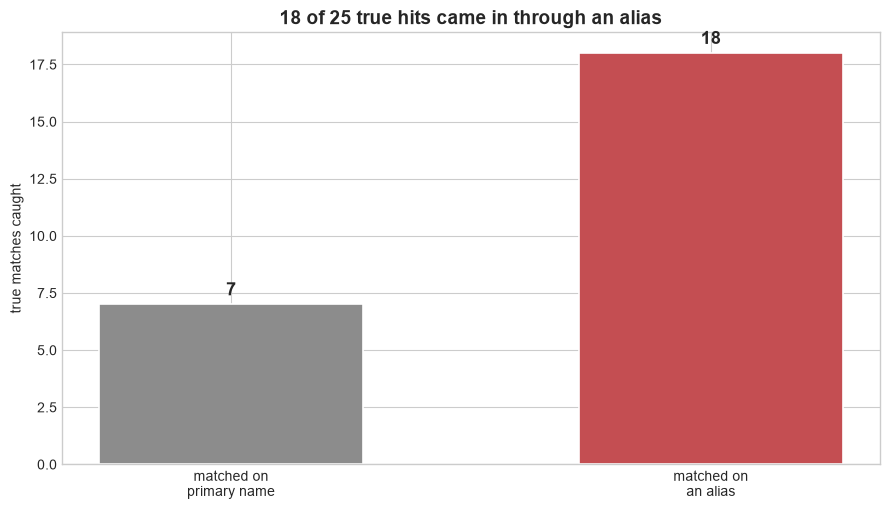

In [7]:
via_alias = 0
for name in true_names:
    result = screen(name, watchlist)
    if result.hits and result.hits[0].matched_alias:
        via_alias += 1
caught = sum(1 for n in true_names if screen(n, watchlist).hits)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.bar(["matched on\nprimary name", "matched on\nan alias"],
       [caught - via_alias, via_alias],
       color=[MUTED, HIT], edgecolor="white", linewidth=1.2, width=0.55)
for i, v in enumerate([caught - via_alias, via_alias]):
    ax.text(i, v + 0.4, str(v), ha="center", fontsize=13, fontweight="bold")
ax.set_title(f"{via_alias} of {caught} true hits came in through an alias")
ax.set_ylabel("true matches caught")
plt.tight_layout(); plt.show()

**Reading:** screen only the primary name and you would lose those hits outright. The
engine scores every AKA with equal weight and records **which string actually matched**
on the alert, so the analyst opening it can see why it fired instead of re-deriving it.

## 4. The alert is only half the control

Raising an alert is not the deliverable. Surviving the examination is. Every alert is
written to a SQLite queue where dispositions are **append-only** and a written rationale
is **mandatory** — a decision you cannot reconstruct months later is worth nothing.

In [8]:
import tempfile, os
from screening import ReviewQueue

queue = ReviewQueue(os.path.join(tempfile.mkdtemp(), "alerts.db"))
result = screen("Muhammad Al Amin Hassan", watchlist)
alert_id = queue.record(result, case_ref="REMED-2026-Q3")[0]

hit = result.hits[0]
print(f"ALERT #{alert_id} — {hit.band} @ {hit.score:.3f}")
print(f"  matched : {hit.entry.name}")
print(f"  via     : {hit.matched_name}  (alias: {hit.matched_alias})")
print(f"  programs: {'|'.join(hit.entry.programs)}   country: {hit.entry.country}")

# An analyst clears it, then a reviewer overturns that call.
queue.disposition(alert_id, "false_positive", "DOB and nationality differ from SDN record", "analyst1")
queue.disposition(alert_id, "true_match",     "DOB confirmed against passport scan", "reviewer2")

print("\nDisposition history (append-only — the first call is not erased):")
for row in queue.history(alert_id):
    print(f"  {row['decided_at']}  {row['decision']:<15} {row['analyst']:<10} {row['rationale']}")

try:
    queue.disposition(alert_id, "false_positive", "   ", "analyst1")
except ValueError as exc:
    print(f"\nRejected, as it should be: {exc}")

ALERT #1 — ESCALATE @ 1.000
  matched : Mohammed Al-Amin Hassan
  via     : Muhammad Al Amin Hassan  (alias: True)
  programs: SDGT   country: Syria

Disposition history (append-only — the first call is not erased):
  2026-08-27T13:09:14+00:00  false_positive  analyst1   DOB and nationality differ from SDN record
  2026-08-27T13:09:14+00:00  true_match      reviewer2  DOB confirmed against passport scan

Rejected, as it should be: a disposition requires a written rationale


**Reading:** the overturned call is still there. An examiner asking *what did you know
and when* gets the sequence, not just the current answer — and a disposition with no
written reason is refused outright rather than stored as a silent gap.

## What this is

Roughly 700 lines of Python, no dependencies outside the standard library, covered by
**35 tests** over normalization, all three matching signals, banding, threshold
behaviour and the queue's audit guarantees.

```bash
pip install -e ".[dev]"
screen name "Muhammad Al Amin Hassan"
screen --db alerts.db --case-ref REMED-2026-Q3 batch onboarding.csv --column customer_name
pytest
```

The watchlist in `data/` is synthetic and every name in it is invented; point
`--watchlist` at the real consolidated list for actual use.